# Building a CHIP-8 Emulator from Scratch

Have you ever wondered how emulators work? How does your computer pretend to be a Game Boy or PlayStation? In this notebook, we'll build a complete emulator for CHIP-8, a simple computer from the 1970s.

By the end, you'll understand the fundamental concepts behind **all** emulators!

## What is Emulation?

**Emulation** is when one computer system mimics the behavior of another. Think of it like this:

- A **real computer** has physical chips (CPU, memory, graphics) that execute instructions
- An **emulator** is software that pretends to be those chips

Instead of electricity flowing through circuits, we use Python code to simulate what would happen!

## Why CHIP-8?

CHIP-8 is perfect for learning because it's **simple but complete**:

| Feature | CHIP-8 | Modern Computer |
|---------|--------|----------------|
| Memory | 4 KB | 8-32 GB |
| Display | 64×32 pixels | 1920×1080+ pixels |
| Instructions | ~35 opcodes | Thousands |
| Colors | 2 (black/white) | Millions |

Despite being simple, CHIP-8 has **all the core concepts** you need to understand emulation!

## The Three Pillars of Emulation

Every emulator needs three things:

1. **State**: Variables that represent the hardware (memory, registers, etc.)
2. **Fetch-Decode-Execute**: Read instructions, figure out what they mean, and do them
3. **Timing**: Run at the correct speed

Let's build each of these step by step!

## Imports

We'll use numpy for arrays and matplotlib for visualization.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Part 1: Understanding the Hardware

Before we can emulate CHIP-8, we need to understand what hardware it has.

### Memory: The Computer's Storage

**Memory** is like a giant array where the computer stores everything:
- The program (instructions to execute)
- Data (numbers, text, etc.)
- Graphics

CHIP-8 has **4096 bytes** (4 KB) of memory. Each byte can store a number from 0-255.

Think of memory as a bunch of numbered boxes:
```
Address:  0x000  0x001  0x002  0x003  ...
Content:  [  0  ][  5  ][ 255 ][ 100 ] ...
```

In [9]:
# Let's create CHIP-8's memory
memory = bytearray(4096)  # 4096 bytes, all starting at 0

print(f"Memory size: {len(memory)} bytes")
print(f"First 10 bytes: {list(memory[0:10])}")

# We can store values in memory
memory[0] = 42
memory[1] = 255
print(f"After storing: {list(memory[0:10])}")

Memory size: 4096 bytes
First 10 bytes: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After storing: [42, 255, 0, 0, 0, 0, 0, 0, 0, 0]


### Memory Layout

CHIP-8 divides memory into sections:

```
0x000-0x1FF  Interpreter (we use this for fonts)
0x200-0xFFF  Program and data
```

Programs always start at address **0x200** (512 in decimal). This is a historical quirk - old interpreters used the first 512 bytes for themselves.

### Registers: Fast Storage

**Registers** are like variables - small, fast storage locations the CPU can use directly.

CHIP-8 has:
- **16 general-purpose registers**: V0, V1, V2, ..., VF (each stores 0-255)
- **VF is special**: Used as a "flag" for certain operations (like detecting collisions or overflows)

Think of registers as the CPU's "workspace" - it's much faster to work with registers than memory!

In [10]:
# Create the 16 registers
V = [0] * 16

# Let's do some math using registers
V[0] = 10  # V0 = 10
V[1] = 20  # V1 = 20
V[2] = V[0] + V[1]  # V2 = V0 + V1

print(f"V0 = {V[0]}")
print(f"V1 = {V[1]}")
print(f"V2 = {V[2]}")
print(f"VF = {V[15]} (the flag register)")

V0 = 10
V1 = 20
V2 = 30
VF = 0 (the flag register)


### Special Registers

CHIP-8 also has some special-purpose registers:

- **I**: A 16-bit register (0-65535) used to store memory addresses
- **PC** (Program Counter): Points to the current instruction
- **SP** (Stack Pointer): Tracks the call stack (we'll use a Python list instead)

In [11]:
I = 0  # Index register
pc = 0x200  # Program counter (starts at 0x200)

print(f"I = 0x{I:04X}")
print(f"PC = 0x{pc:03X} (this is where our program starts!)")

I = 0x0000
PC = 0x200 (this is where our program starts!)


### The Display

CHIP-8 has a **64×32 monochrome display**. Each pixel is either ON (1) or OFF (0).

We'll represent this as a 2D array.

Display dimensions: 32×64


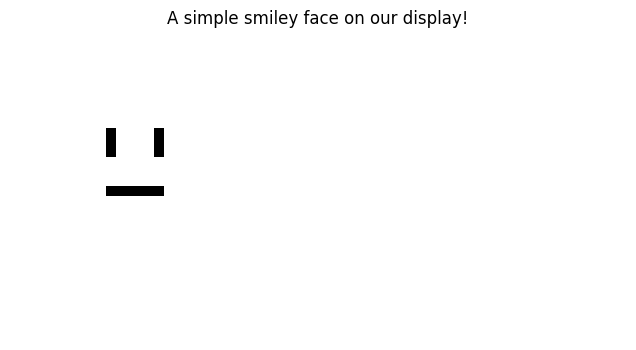

In [12]:
display = [[0] * 64 for _ in range(32)]

print(f"Display dimensions: {len(display)}×{len(display[0])}")

# Let's turn on some pixels to draw a smiley face
for x in [10, 15]:  # Eyes
    for y in range(10, 13):
        display[y][x] = 1

for x in range(10, 16):  # Smile
    display[16][x] = 1

# Visualize it
plt.figure(figsize=(8, 4))
plt.imshow(display, cmap='binary', interpolation='nearest')
plt.title('A simple smiley face on our display!')
plt.axis('off')
plt.show()

### The Stack

The **stack** is used to remember where to return after calling a function (subroutine).

Think of it like a stack of plates - you can only add/remove from the top:
- **Push**: Add something to the stack
- **Pop**: Remove and return the top item

In [13]:
stack = []

# When we call a function, push the return address
stack.append(0x300)
print(f"Stack after CALL: {stack}")

stack.append(0x400)
print(f"Stack after another CALL: {stack}")

# When we return, pop the address
return_addr = stack.pop()
print(f"Returned to: 0x{return_addr:03X}")
print(f"Stack after RETURN: {stack}")

Stack after CALL: [768]
Stack after another CALL: [768, 1024]
Returned to: 0x400
Stack after RETURN: [768]


## Part 2: Instructions and Opcodes

Now for the exciting part - understanding how computers execute instructions!

### What is an Instruction?

An **instruction** tells the computer to do something specific:
- "Add 5 to register V0"
- "Jump to address 0x300"
- "Draw a sprite at position (10, 20)"

In CHIP-8, instructions are encoded as **16-bit numbers** called **opcodes**.

For example:
- `0x6005` means "Set V0 = 5"
- `0x700A` means "Add 10 to V0"

### Decoding an Opcode

An opcode is a 16-bit number, but different parts mean different things:

```
Opcode: 0x6A15
Binary: 0110 1010 0001 0101
        ^^^^ ^^^^ ^^^^ ^^^^
         |    |    |    |
      first  X    N    N  (different parts have names)
```

We extract these parts using **bitwise operations**:
- `first`: First nibble (4 bits) - tells us what type of instruction
- `X`, `Y`: Register numbers
- `N`, `NN`, `NNN`: Values or addresses

In [14]:
opcode = 0x6A15

# Extract the parts using bit masking and shifting
first = (opcode & 0xF000) >> 12  # Get first 4 bits
x = (opcode & 0x0F00) >> 8       # Get second 4 bits
nn = opcode & 0x00FF             # Get last 8 bits

print(f"Opcode: 0x{opcode:04X}")
print(f"  first = 0x{first:X} (instruction type)")
print(f"  x     = 0x{x:X} (register number)")
print(f"  nn    = 0x{nn:02X} (value)")
print(f"\nMeaning: Set V{x:X} = {nn}")

Opcode: 0x6A15
  first = 0x6 (instruction type)
  x     = 0xA (register number)
  nn    = 0x15 (value)

Meaning: Set VA = 21


### Understanding Bit Operations

Let's visualize how we extract parts of an opcode:

In [15]:
def visualize_opcode(opcode):
    """Show how an opcode is broken down"""
    binary = f"{opcode:016b}"
    print(f"Opcode: 0x{opcode:04X}")
    print(f"Binary: {binary[0:4]} {binary[4:8]} {binary[8:12]} {binary[12:16]}")
    print(f"        ^^^^ ^^^^ ^^^^ ^^^^")
    print(f"        first  X    Y    N")
    print()
    
    first = (opcode & 0xF000) >> 12
    x = (opcode & 0x0F00) >> 8
    y = (opcode & 0x00F0) >> 4
    n = opcode & 0x000F
    nn = opcode & 0x00FF
    nnn = opcode & 0x0FFF
    
    print(f"Extracted values:")
    print(f"  first = {first} (0x{first:X})")
    print(f"  x     = {x} (V{x:X})")
    print(f"  y     = {y} (V{y:X})")
    print(f"  n     = {n}")
    print(f"  nn    = {nn} (0x{nn:02X})")
    print(f"  nnn   = {nnn} (0x{nnn:03X})")

visualize_opcode(0x6A15)  # Set VA = 0x15
print("\n" + "="*50 + "\n")
visualize_opcode(0x8014)  # V0 = V0 + V1

Opcode: 0x6A15
Binary: 0110 1010 0001 0101
        ^^^^ ^^^^ ^^^^ ^^^^
        first  X    Y    N

Extracted values:
  first = 6 (0x6)
  x     = 10 (VA)
  y     = 1 (V1)
  n     = 5
  nn    = 21 (0x15)
  nnn   = 2581 (0xA15)


Opcode: 0x8014
Binary: 1000 0000 0001 0100
        ^^^^ ^^^^ ^^^^ ^^^^
        first  X    Y    N

Extracted values:
  first = 8 (0x8)
  x     = 0 (V0)
  y     = 1 (V1)
  n     = 4
  nn    = 20 (0x14)
  nnn   = 20 (0x014)


### The Fetch-Decode-Execute Cycle

This is the **heart of every CPU and emulator**!

1. **Fetch**: Read the next instruction from memory
2. **Decode**: Figure out what the instruction means
3. **Execute**: Do what the instruction says
4. **Repeat**: Go back to step 1

Let's implement each step!

### Step 1: Fetching an Instruction

Instructions are 16-bit (2 bytes), but memory stores 8-bit bytes. So we need to read **two consecutive bytes** and combine them.

In [16]:
# Create a simple program in memory
memory = bytearray(4096)
memory[0x200] = 0x60  # First byte of instruction
memory[0x201] = 0x05  # Second byte of instruction

# Fetch the instruction
pc = 0x200
byte1 = memory[pc]
byte2 = memory[pc + 1]

# Combine them into a 16-bit opcode
opcode = (byte1 << 8) | byte2

print(f"PC = 0x{pc:03X}")
print(f"Byte 1: 0x{byte1:02X}")
print(f"Byte 2: 0x{byte2:02X}")
print(f"Opcode: 0x{opcode:04X} (this means: Set V0 = 5)")

PC = 0x200
Byte 1: 0x60
Byte 2: 0x05
Opcode: 0x6005 (this means: Set V0 = 5)


## Part 3: Building the Emulator

Now let's put it all together! We'll create a class that contains all the hardware state and can execute instructions.

### Font Data

CHIP-8 has built-in sprites for hexadecimal digits (0-F). Each digit is 5 bytes tall and 4 pixels wide.

These fonts are stored in the first 80 bytes of memory.

In [17]:
FONT_SET = [
    0xF0, 0x90, 0x90, 0x90, 0xF0,  # 0
    0x20, 0x60, 0x20, 0x20, 0x70,  # 1
    0xF0, 0x10, 0xF0, 0x80, 0xF0,  # 2
    0xF0, 0x10, 0xF0, 0x10, 0xF0,  # 3
    0x90, 0x90, 0xF0, 0x10, 0x10,  # 4
    0xF0, 0x80, 0xF0, 0x10, 0xF0,  # 5
    0xF0, 0x80, 0xF0, 0x90, 0xF0,  # 6
    0xF0, 0x10, 0x20, 0x40, 0x40,  # 7
    0xF0, 0x90, 0xF0, 0x90, 0xF0,  # 8
    0xF0, 0x90, 0xF0, 0x10, 0xF0,  # 9
    0xF0, 0x90, 0xF0, 0x90, 0x90,  # A
    0xE0, 0x90, 0xE0, 0x90, 0xE0,  # B
    0xF0, 0x80, 0x80, 0x80, 0xF0,  # C
    0xE0, 0x90, 0x90, 0x90, 0xE0,  # D
    0xF0, 0x80, 0xF0, 0x80, 0xF0,  # E
    0xF0, 0x80, 0xF0, 0x80, 0x80   # F
]

### Visualizing the Fonts

Let's see what these font sprites look like!

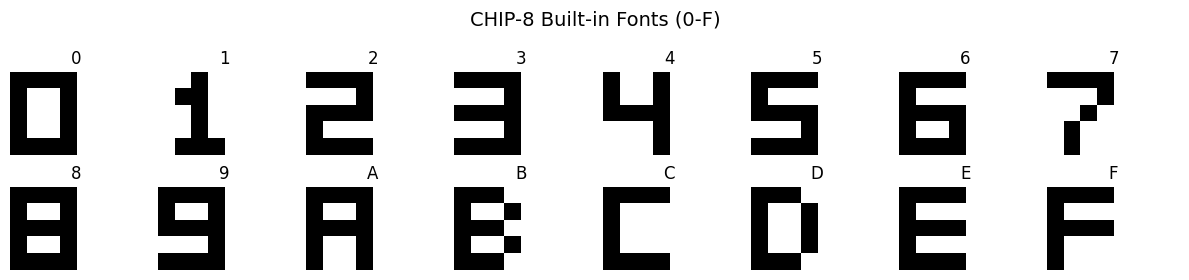

In [18]:
def draw_font_sprite(sprite_bytes):
    """Convert 5 bytes into a 5×8 pixel array"""
    pixels = []
    for byte in sprite_bytes:
        row = [(byte >> (7-i)) & 1 for i in range(8)]
        pixels.append(row)
    return pixels

# Visualize all 16 digits
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
axes = axes.flatten()

for i in range(16):
    sprite_bytes = FONT_SET[i*5:(i+1)*5]
    pixels = draw_font_sprite(sprite_bytes)
    axes[i].imshow(pixels, cmap='binary', interpolation='nearest')
    axes[i].set_title(f'{i:X}')
    axes[i].axis('off')

plt.suptitle('CHIP-8 Built-in Fonts (0-F)', fontsize=14)
plt.tight_layout()
plt.show()

### The Complete Chip8 Class

Now we'll create our emulator! This class contains:
- All the hardware state (memory, registers, display, etc.)
- Methods to load programs and execute instructions

In [19]:
class Chip8:
    def __init__(self):
        # Hardware state
        self.memory = bytearray(4096)
        self.V = [0] * 16  # 16 registers
        self.I = 0  # Index register
        self.pc = 0x200  # Program counter
        self.display = [[0] * 64 for _ in range(32)]
        self.stack = []
        self.delay_timer = 0
        self.sound_timer = 0
        self.keys = [0] * 16
        self.draw_flag = False
        
        # Load fonts into memory
        for i, byte in enumerate(FONT_SET):
            self.memory[i] = byte
    
    def load_program(self, program):
        """Load a program into memory starting at 0x200"""
        for i, byte in enumerate(program):
            self.memory[0x200 + i] = byte
    
    def fetch(self):
        """Fetch the next 16-bit instruction"""
        opcode = (self.memory[self.pc] << 8) | self.memory[self.pc + 1]
        return opcode
    
    def execute(self, opcode):
        """Decode and execute an instruction"""
        # Decode the opcode
        first = (opcode & 0xF000) >> 12
        x = (opcode & 0x0F00) >> 8
        y = (opcode & 0x00F0) >> 4
        n = opcode & 0x000F
        nn = opcode & 0x00FF
        nnn = opcode & 0x0FFF
        
        # Move to next instruction (most instructions do this)
        self.pc += 2
        
        # Execute based on the first nibble
        if opcode == 0x00E0:
            # Clear screen
            self.display = [[0] * 64 for _ in range(32)]
            self.draw_flag = True
        
        elif opcode == 0x00EE:
            # Return from subroutine
            self.pc = self.stack.pop()
        
        elif first == 0x1:
            # Jump to address NNN
            self.pc = nnn
        
        elif first == 0x2:
            # Call subroutine at NNN
            self.stack.append(self.pc)
            self.pc = nnn
        
        elif first == 0x3:
            # Skip next if VX == NN
            if self.V[x] == nn:
                self.pc += 2
        
        elif first == 0x4:
            # Skip next if VX != NN
            if self.V[x] != nn:
                self.pc += 2
        
        elif first == 0x5:
            # Skip next if VX == VY
            if self.V[x] == self.V[y]:
                self.pc += 2
        
        elif first == 0x6:
            # Set VX = NN
            self.V[x] = nn
        
        elif first == 0x7:
            # Add NN to VX
            self.V[x] = (self.V[x] + nn) & 0xFF
        
        elif first == 0x8:
            # Register operations
            if n == 0x0:
                self.V[x] = self.V[y]
            elif n == 0x1:
                self.V[x] |= self.V[y]
            elif n == 0x2:
                self.V[x] &= self.V[y]
            elif n == 0x3:
                self.V[x] ^= self.V[y]
            elif n == 0x4:
                result = self.V[x] + self.V[y]
                self.V[0xF] = 1 if result > 0xFF else 0
                self.V[x] = result & 0xFF
            elif n == 0x5:
                self.V[0xF] = 1 if self.V[x] >= self.V[y] else 0
                self.V[x] = (self.V[x] - self.V[y]) & 0xFF
        
        elif first == 0x9:
            # Skip next if VX != VY
            if self.V[x] != self.V[y]:
                self.pc += 2
        
        elif first == 0xA:
            # Set I = NNN
            self.I = nnn
        
        elif first == 0xC:
            # Set VX = random & NN
            self.V[x] = random.randint(0, 255) & nn
        
        elif first == 0xD:
            # Draw sprite at (VX, VY)
            self.draw_sprite(x, y, n)
        
        elif first == 0xF:
            if nn == 0x29:
                # Set I = location of sprite for digit VX
                self.I = self.V[x] * 5
            elif nn == 0x33:
                # Store BCD of VX
                self.memory[self.I] = self.V[x] // 100
                self.memory[self.I + 1] = (self.V[x] // 10) % 10
                self.memory[self.I + 2] = self.V[x] % 10
    
    def draw_sprite(self, x, y, n):
        """Draw an N-byte sprite at position (VX, VY)"""
        vx = self.V[x] % 64
        vy = self.V[y] % 32
        self.V[0xF] = 0  # Reset collision flag
        
        for row in range(n):
            if vy + row >= 32:
                break
            
            sprite_byte = self.memory[self.I + row]
            
            for col in range(8):
                if vx + col >= 64:
                    break
                
                # Check if this pixel should be drawn
                if (sprite_byte >> (7 - col)) & 1:
                    # XOR with existing pixel (collision detection)
                    if self.display[vy + row][vx + col] == 1:
                        self.V[0xF] = 1  # Collision detected!
                    self.display[vy + row][vx + col] ^= 1
        
        self.draw_flag = True
    
    def cycle(self):
        """Execute one CPU cycle (fetch-decode-execute)"""
        opcode = self.fetch()
        self.execute(opcode)

print("✓ Chip8 emulator created!")

✓ Chip8 emulator created!


## Part 4: Testing the Emulator

Let's write some simple programs to test our emulator!

### Test 1: Basic Arithmetic

Let's write a program that:
1. Sets V0 = 5
2. Adds 10 to V0
3. Result should be 15

In [20]:
chip8 = Chip8()

# Our program (in machine code)
program = [
    0x60, 0x05,  # 0x6005: Set V0 = 5
    0x70, 0x0A,  # 0x700A: Add 10 to V0
]

chip8.load_program(program)

print(f"Before: V0 = {chip8.V[0]}")

# Execute first instruction
chip8.cycle()
print(f"After V0 = 5: V0 = {chip8.V[0]}")

# Execute second instruction
chip8.cycle()
print(f"After V0 += 10: V0 = {chip8.V[0]}")

assert chip8.V[0] == 15, "Test failed!"
print("\n✓ Test passed! Our emulator works!")

Before: V0 = 0
After V0 = 5: V0 = 5
After V0 += 10: V0 = 15

✓ Test passed! Our emulator works!


### Understanding XOR Graphics

CHIP-8 uses **XOR** (exclusive OR) to draw sprites. This is clever because:
- Drawing the same sprite twice erases it
- We can detect collisions (when a pixel turns OFF)

Let's see how XOR works:

In [21]:
# XOR truth table
print("XOR Truth Table:")
print("0 XOR 0 =", 0 ^ 0)
print("0 XOR 1 =", 0 ^ 1)
print("1 XOR 0 =", 1 ^ 0)
print("1 XOR 1 =", 1 ^ 1)
print("\nNotice: XORing the same value twice returns to original!")

# Demonstration
value = 1
print(f"\nStart: {value}")
value ^= 1
print(f"After XOR 1: {value}")
value ^= 1
print(f"After XOR 1 again: {value}  (back to original!)")

XOR Truth Table:
0 XOR 0 = 0
0 XOR 1 = 1
1 XOR 0 = 1
1 XOR 1 = 0

Notice: XORing the same value twice returns to original!

Start: 1
After XOR 1: 0
After XOR 1 again: 1  (back to original!)


### Test 2: Drawing a Digit

Let's use our emulator to draw something on the screen!

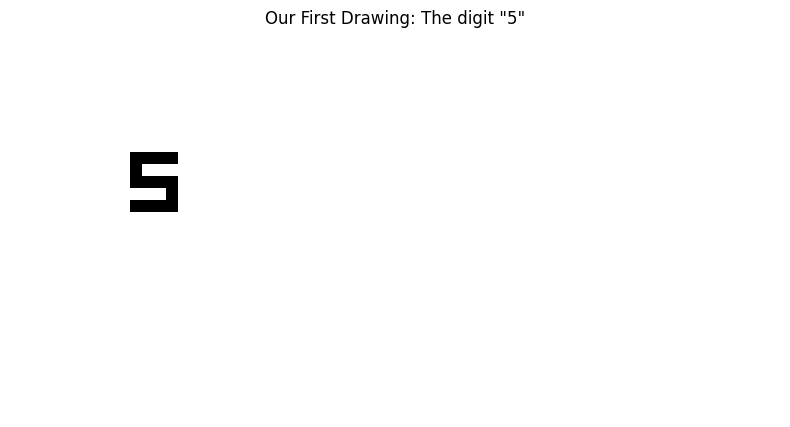

I register = 0x019 (points to font data for '5')
Font data starts at: 0x019


In [22]:
chip8 = Chip8()

program = [
    0x60, 0x0A,  # V0 = 10 (x position)
    0x61, 0x0A,  # V1 = 10 (y position)
    0x62, 0x05,  # V2 = 5 (which digit to draw)
    0xF2, 0x29,  # I = location of sprite for digit in V2
    0xD0, 0x15,  # Draw 5-byte sprite at (V0, V1)
]

chip8.load_program(program)

# Execute all 5 instructions
for i in range(5):
    chip8.cycle()

# Visualize the result
plt.figure(figsize=(10, 5))
plt.imshow(chip8.display, cmap='binary', interpolation='nearest')
plt.title('Our First Drawing: The digit "5"')
plt.axis('off')
plt.show()

print(f"I register = 0x{chip8.I:03X} (points to font data for '5')")
print(f"Font data starts at: 0x{5*5:03X}")

### Test 3: Draw All Hexadecimal Digits

Let's create a program that draws all 16 digits (0-F) to showcase our emulator!

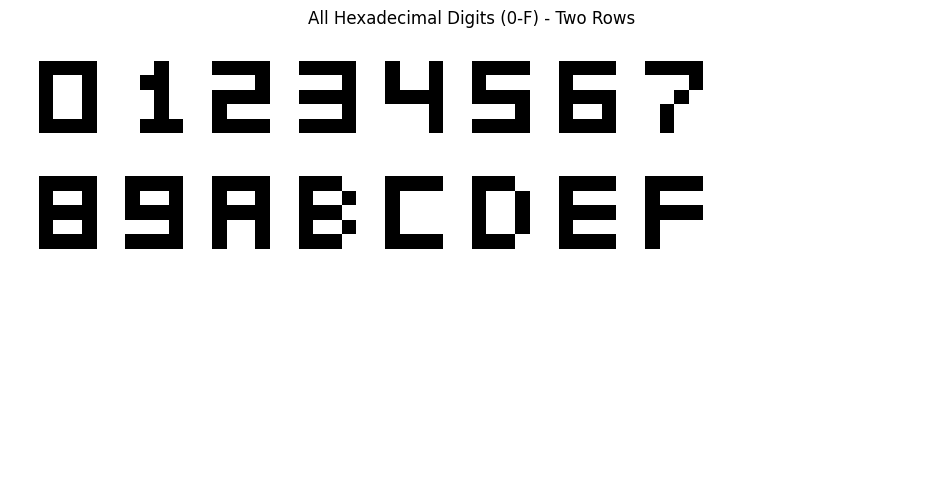

Executed 80 instructions
Drew 16 different digits


In [23]:
chip8 = Chip8()

# Generate a program that draws all 16 digits
program = []
for digit in range(16):
    x_pos = (digit % 8) * 6 + 2  # Spread across 8 columns
    y_pos = (digit // 8) * 8 + 2  # Two rows
    
    program.extend([
        0x60, x_pos,    # V0 = x position
        0x61, y_pos,    # V1 = y position
        0x62, digit,    # V2 = which digit
        0xF2, 0x29,     # I = sprite location
        0xD0, 0x15,     # Draw sprite
    ])

chip8.load_program(program)

# Execute the entire program
for _ in range(len(program) // 2):
    chip8.cycle()

plt.figure(figsize=(12, 6))
plt.imshow(chip8.display, cmap='binary', interpolation='nearest')
plt.title('All Hexadecimal Digits (0-F) - Two Rows')
plt.axis('off')
plt.show()

print(f"Executed {len(program) // 2} instructions")
print(f"Drew {16} different digits")

## Part 5: The Classic IBM Logo Demo

One of the most famous CHIP-8 programs is the IBM logo test. Let's run it!

### Understanding the IBM Logo Program

This program is special because:
- It includes custom sprite data (not just the built-in fonts)
- The sprites are embedded in the program itself
- It demonstrates how programs can store and use their own graphics

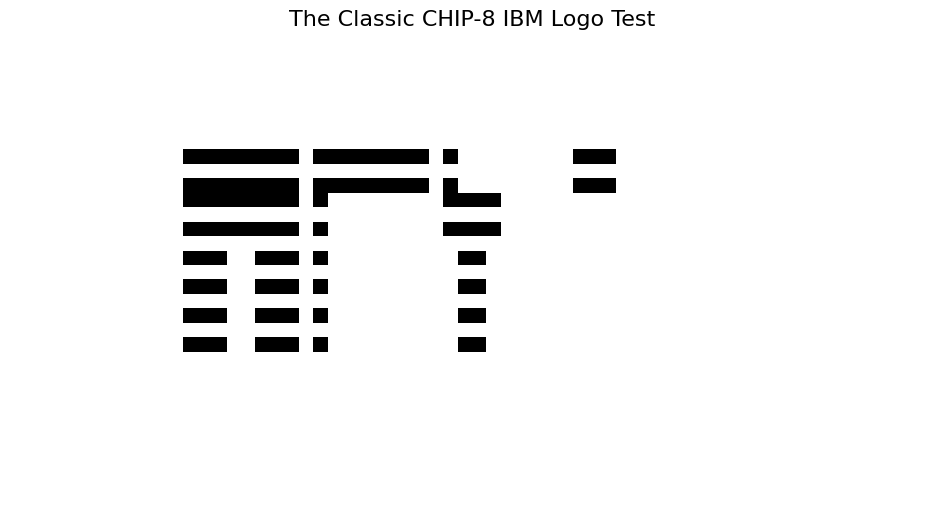

✓ IBM Logo rendered successfully!
This was a common test ROM used to verify CHIP-8 emulators.


In [24]:
# The famous IBM logo program
ibm_logo = [
    # Instructions
    0x00, 0xE0,  # Clear screen
    0xA2, 0x2A,  # I = 0x22A (address of first sprite)
    0x60, 0x0C,  # V0 = 12 (x position)
    0x61, 0x08,  # V1 = 8 (y position)
    0xD0, 0x1F,  # Draw 15-byte sprite (letter 'I')
    0x70, 0x09,  # V0 += 9 (move right)
    0xA2, 0x39,  # I = 0x239 (address of second sprite)
    0xD0, 0x1F,  # Draw 15-byte sprite (letter 'B')
    0xA2, 0x48,  # I = 0x248 (address of third sprite)
    0x70, 0x09,  # V0 += 9 (move right)
    0xD0, 0x1F,  # Draw 15-byte sprite (letter 'M')
    0x70, 0x09,  # V0 += 9 (move right)
    0xA2, 0x57,  # I = 0x257 (address of fourth sprite)
    0xD0, 0x1F,  # Draw 15-byte sprite (another 'M')
    0x12, 0x28,  # Jump to 0x228 (infinite loop)
    
    # Sprite data for 'I'
    0xFF, 0x00, 0xFF, 0x00, 0x3C, 0x00, 0x3C, 0x00,
    0x3C, 0x00, 0x3C, 0x00, 0xFF, 0x00, 0xFF,
    
    # Sprite data for 'B'
    0xFF, 0x00, 0xFF, 0x00, 0xE7, 0x00, 0xE7, 0x00,
    0xE7, 0x00, 0xE7, 0x00, 0xFF, 0x00, 0xFF,
    
    # Sprite data for first 'M'
    0x80, 0x00, 0x80, 0x00, 0x80, 0x00, 0x80, 0x00,
    0x80, 0x00, 0x80, 0x00, 0x80, 0x00, 0x80,
    
    # Sprite data for second 'M'
    0xF0, 0x00, 0xF0, 0x00, 0x60, 0x00, 0x60, 0x00,
    0x60, 0x00, 0x60, 0x00, 0xE0, 0x00, 0xE0,
]

chip8 = Chip8()
chip8.load_program(ibm_logo)

# Execute until we hit the infinite loop
for _ in range(30):
    chip8.cycle()
    if chip8.pc == 0x228:  # The jump target
        break

plt.figure(figsize=(12, 6))
plt.imshow(chip8.display, cmap='binary', interpolation='nearest')
plt.title('The Classic CHIP-8 IBM Logo Test', fontsize=16)
plt.axis('off')
plt.show()

print("✓ IBM Logo rendered successfully!")
print("This was a common test ROM used to verify CHIP-8 emulators.")

## Congratulations!

You've built a working emulator! Here's what you learned:

### Key Concepts Mastered

1. **Emulation Fundamentals**
   - Simulating hardware with software
   - Representing state (memory, registers, display)
   - The fetch-decode-execute cycle

2. **Binary and Bit Operations**
   - How instructions are encoded as numbers
   - Extracting parts of opcodes using bit masks
   - Bit shifting and manipulation

3. **Computer Architecture**
   - Memory organization
   - Registers and their purpose
   - The program counter and stack
   - Memory-mapped graphics

4. **Graphics**
   - Sprite-based rendering
   - XOR drawing (and why it's clever)
   - Collision detection

### What Makes This Special?

The principles you learned apply to **all emulators**:

- Game Boy emulators: Same idea, just more registers and instructions
- PlayStation emulators: Same concept, more complex graphics
- Virtual machines (Java, Python): Also use fetch-decode-execute!

You now understand the **fundamental technique** behind running old games, cross-platform apps, and even modern virtual machines!

### Next Steps

Want to go further? Try:

1. **Add more opcodes**: Implement keyboard input, timers, and sound
2. **Load ROM files**: Read actual CHIP-8 game files from disk
3. **Build a GUI**: Use pygame or tkinter to create a window
4. **Add debugging tools**: Disassembler, breakpoints, step-through execution
5. **Try SUPER-CHIP**: An extended version with more features
6. **Study other systems**: Game Boy, NES, or even x86 architecture

### The Big Picture

Emulation shows us that computers are **universal machines** - they can simulate any other computer! This is why:

- You can play retro games on modern hardware
- Developers can test iOS apps on Mac
- Cloud servers can run thousands of "virtual" machines
- Programming languages can be "interpreted" (Python, JavaScript)

All of these use the same core idea: **simulate the hardware with software**.

You've just built your first emulator - congratulations! 🎉